In [2]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from metrics import truthfulness

plt.rcParams.update({
    "font.size": 14,            # base text size
    "axes.titlesize": 16,       # subplot titles
    "axes.labelsize": 15,       # x/y labels
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "figure.titlesize": 18      # suptitle size
})


In [4]:
def load_beliefs(filename):
    beliefs = np.load(filename)
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3) 
    T = T_0[1::]
    t = np.arange(1, len(T_0))

    return q_0, p_0, T, t



def merge_simulation_files(folder, delete_originals=False, verbose=True):
    """
    Merge .npz cluster result files in `folder` that differ only by 'numsim###' in filename.
    Concatenates simulation arrays along axis=0, verifies conspirator_frac consistency,
    writes a new file with updated numsim inferred from concatenated arrays.

    Returns: list of output filepaths created.
    """
    files = [f for f in os.listdir(folder) if f.endswith(".npz")]
    if not files:
        if verbose: print("No .npz files found in folder.")
        return []

    # Group files by filename with numsim\d+ replaced by a placeholder token
    groups = {}
    for f in files:
        # Replace the substring numsim### (digits) with a placeholder 'numsim'
        key = re.sub(r"numsim\d+", "numsim", f)
        groups.setdefault(key, []).append(f)

    created = []

    for key, file_list in groups.items():
        if len(file_list) < 2:
            # nothing to merge
            if verbose:
                print(f"Skipping group (single file): {file_list[0]}")
            continue

        if verbose:
            print(f"\nMerging {len(file_list)} files for group: {key}")

        # Sort file_list to have deterministic order (optional)
        file_list = sorted(file_list)

        merged_data = {}
        base_conspirator_frac = None
        first_keys = None

        for i, fname in enumerate(file_list):
            path = os.path.join(folder, fname)
            data = dict(np.load(path, allow_pickle=False))

            if i == 0:
                # initialize merged_data with lists for concatenation
                first_keys = list(data.keys())
                for k in first_keys:
                    # conspirator_frac is expected to be 1-D (same across files)
                    merged_data[k] = [data[k]]
                base_conspirator_frac = data.get("conspirator_frac", None)
            else:
                # ensure same keys
                if set(data.keys()) != set(first_keys):
                    raise ValueError(f"File {fname} has different keys than {file_list[0]}.\n"
                                     f"{fname} keys: {sorted(data.keys())}\n"
                                     f"{file_list[0]} keys: {sorted(first_keys)}")
                # check conspirator_frac equality if present
                cf = data.get("conspirator_frac", None)
                if base_conspirator_frac is not None:
                    if cf is None:
                        raise ValueError(f"{fname} missing 'conspirator_frac' but expected.")
                    if not np.allclose(base_conspirator_frac, cf, atol=1e-12, rtol=1e-8):
                        raise ValueError(f"'conspirator_frac' mismatch between {file_list[0]} and {fname}. Aborting merge.")
                # append arrays
                for k in first_keys:
                    merged_data[k].append(data[k])

        # Now concatenate lists along axis=0 for arrays that are per-simulation.
        # For conspirator_frac (1D), keep only the first.
        final = {}
        for k, list_of_arrays in merged_data.items():
            # If arrays are 1D and length equals conspirator_frac length, keep single copy
            arr0 = list_of_arrays[0]
            # Decide whether to concatenate:
            # If arr0.ndim >= 2 we treat it as per-simulation and concat along axis 0.
            # If arr0 is 1-D and equal to base_conspirator_frac, keep only one copy.
            if arr0.ndim >= 2:
                try:
                    final[k] = np.concatenate(list_of_arrays, axis=0)
                except ValueError as e:
                    raise ValueError(f"Could not concatenate key '{k}': {e}")
            else:
                # 1D arrays: if key is 'conspirator_frac' keep first, else try to concat anyway
                if k == "conspirator_frac":
                    final[k] = arr0  # already checked equality
                else:
                    # If shapes match per-simulation (e.g., maybe stored as (num_sims,)), concat
                    try:
                        final[k] = np.concatenate([a if a.ndim>0 else np.atleast_1d(a) for a in list_of_arrays], axis=0)
                    except Exception:
                        # fallback: keep first
                        final[k] = arr0

        # infer total numsim from one of the concatenated arrays
        # look for a per-simulation array: prefer 'num_clusters' or 'truthfulness_largest_cluster'
        sample_key = None
        for candidate in ["num_clusters", "truthfulness_largest_cluster", "largest_cluster_size", "trust_largest_cluster"]:
            if candidate in final:
                sample_key = candidate
                break
        if sample_key is None:
            # fallback: pick any array with ndim >= 2
            for k, v in final.items():
                if getattr(v, "ndim", 0) >= 2:
                    sample_key = k
                    break
        if sample_key is None:
            raise ValueError("Could not determine per-simulation array to infer total numsim.")

        total_num_sim = final[sample_key].shape[0]

        # Build new filename: replace numsim\d+ in the first filename with updated count
        original_fname = file_list[0]
        if re.search(r"numsim\d+", original_fname):
            new_fname = re.sub(r"numsim\d+", f"numsim{total_num_sim}", original_fname)
        else:
            # If no numsim tag found, append it before extension
            base_noext, ext = os.path.splitext(original_fname)
            new_fname = f"{base_noext}_numsim{total_num_sim}{ext}"

        out_path = os.path.join(folder, new_fname)

        # Save compressed
        np.savez_compressed(out_path, **final)
        created.append(out_path)
        if verbose:
            print(f"Saved merged file: {new_fname}  (total simulations = {total_num_sim})")

        if delete_originals:
            for f in file_list:
                os.remove(os.path.join(folder, f))
            if verbose:
                print("Deleted original files.")

    if verbose:
        print("\nMerging complete.")
    return created





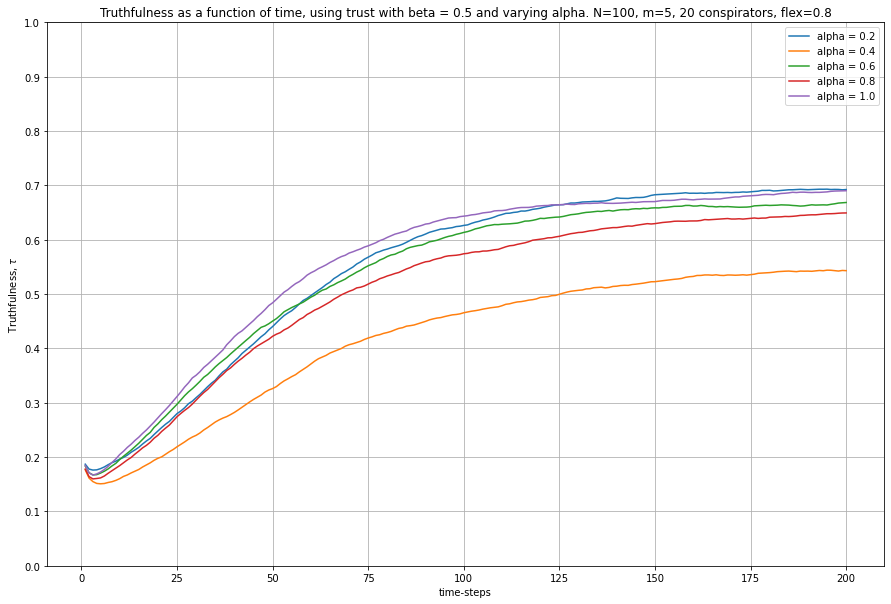

In [10]:
plt.figure(figsize=(15, 10))

alpha_arr = np.arange(0.2, 1.2, 0.2)
for alpha in alpha_arr:
    q, p, T, t = load_beliefs(f"N100_trust_a{alpha:.1f}_b0.5_thr1.0_numsim50_timesteps200_flex0.8_BA_consp20_timeev.npz")
    plt.plot(t, T, label=f"alpha = {alpha:.1f}")

plt.grid()
plt.yticks(np.arange(0, 1.1, 0.1))
#plt.ylim(0, 0.4)
#plt.xlim(0, 25)
#plt.yscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Truthfulness as a function of time, using trust with beta = 0.5 and varying alpha. N=100, m=5, 20 conspirators, flex=0.8")
plt.savefig("alpha_20_consp.png")
plt.show()

In [5]:
def load_cluster_data(fname):
    data = np.load(fname)

    metrics = {
        "conspirator_frac": data["conspirator_frac"],
        "num_clusters": data["num_clusters"],
        "largest_cluster_size": data["largest_cluster_size"],
        "truthfulness_largest_cluster": data["truthfulness_largest_cluster"],
        "trust_largest_cluster": data["trust_largest_cluster"],
    }

    # Averages along simulation axis=0 (same as your original)
    metrics_avg = {
        k + "_avg": np.average(v, axis=0) for k, v in metrics.items()
    }

    return {**metrics, **metrics_avg}



def plot_cluster_results(folder, N, network_type, update_type, flex, m=None, k=None, time=250, xticks=np.arange(0, 0.65, 0.1), edit_ax4=False):

    assert network_type in ["BA", "ER"], "network_type must be 'BA' or 'ER'"
    assert update_type in ["linear", "log"], "update_type must be 'linear' or 'log'"

    files = [f for f in os.listdir(folder) if f.endswith(".npz")]

    # Helper to extract beta values from filenames
    def extract_beta(f):
        if "_b" in f:
            try:
                return float(f.split("_b")[1].split("_")[0])
            except:
                return None
        return None

    trust_files = [f for f in files if "trust" in f.lower()]
    uniform_files = [f for f in files if "uniform" in f.lower()]
    trust_files = sorted(trust_files, key=extract_beta)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()
    capsize=4

    for f in trust_files:
        metrics = load_cluster_data(os.path.join(folder, f))
        beta = extract_beta(f)
        label = f"β={beta:.1f}" if beta is not None else f

        x = metrics["conspirator_frac"]

        ax1.errorbar(
            x,
            metrics["truthfulness_largest_cluster_avg"],
            yerr=np.std(metrics["truthfulness_largest_cluster"], axis=0),#/np.sqrt(metrics["truthfulness_largest_cluster"].shape[0]),
            fmt="-", lw=2, capsize=capsize, label=label
        )

        ax2.errorbar(
            x,
            metrics["num_clusters_avg"],
            yerr=np.std(metrics["num_clusters"], axis=0),#/np.sqrt(metrics["num_clusters"].shape[0]),
            fmt="-", lw=2, capsize=capsize
        )

        ax3.errorbar(
            x,
            metrics["largest_cluster_size_avg"],
            yerr=np.std(metrics["largest_cluster_size"], axis=0),#/np.sqrt(metrics["largest_cluster_size"].shape[0]),
            fmt="-", lw=2, capsize=capsize
        )

        ax4.errorbar(
            x,
            metrics["trust_largest_cluster_avg"],
            yerr=np.std(metrics["trust_largest_cluster"], axis=0),#/np.sqrt(metrics["trust_largest_cluster"].shape[0]),
            fmt="-", lw=2, capsize=capsize
        )



    for f in uniform_files:
        metrics = load_cluster_data(os.path.join(folder, f))
        x = metrics["conspirator_frac"]

        ax1.errorbar(
            x,
            metrics["truthfulness_largest_cluster_avg"],
            yerr=np.std(metrics["truthfulness_largest_cluster"], axis=0),#/np.sqrt(metrics["truthfulness_largest_cluster"].shape[0]),
            fmt="-", lw=2, capsize=capsize, label="uniform"
        )


        ax2.errorbar(
            x,
            metrics["num_clusters_avg"],
            yerr=np.std(metrics["num_clusters"], axis=0),#/np.sqrt(metrics["num_clusters"].shape[0]),
            fmt="-", lw=2, capsize=capsize
        )

        ax3.errorbar(
            x,
            metrics["largest_cluster_size_avg"],
            yerr=np.std(metrics["largest_cluster_size"], axis=0),#/np.sqrt(metrics["largest_cluster_size"].shape[0]),
            fmt="-", lw=2, capsize=capsize
        )

        ax4.errorbar(
            x,
            metrics["trust_largest_cluster_avg"],
            yerr=np.std(metrics["trust_largest_cluster"], axis=0),#/np.sqrt(metrics["trust_largest_cluster"].shape[0]),
            fmt="-", lw=2, capsize=capsize
        )


    # Formatting
    for ax in axes.flatten():
        ax.grid(True)
        ax.set_xlabel("Fraction of conspirators")
        ax.set_xticks(xticks)

    ax1.set_ylabel("Truthfulness")
    ax2.set_ylabel("Number of clusters")
    ax3.set_ylabel("Size of largest cluster")
    ax4.set_ylabel("Trust in largest cluster")

    ax1.set_title("Average truthfulness of largest cluster")
    ax2.set_title("Average number of clusters")
    ax3.set_title("Average size of largest cluster")
    ax4.set_title("Average direct trust in largest cluster")

    if edit_ax4:
        ax4.set_ylim([0.7, 1])

    # Title generation
    param_part = f"{network_type}-network, N={N}, flex={flex}, {update_type} updates"
    if network_type == "BA": param_part += f", m={m}"
    if network_type == "ER": param_part += f", k={k}"

    title = f"Clusters at {time} time steps. {param_part}"

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    fig.legend(loc="center right", bbox_to_anchor=(1, 0.5))

    save_name = title.replace(" ", "_").replace(",", "") + ".png"
    save_path = os.path.join(folder, save_name)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved to:", save_path)






In [17]:


def _extract_beta(fname):
    if "_b" in fname:
        try:
            return float(fname.split("_b")[1].split("_")[0])
        except:
            return None
    return None

    
def plot_truthfulness_results(folder, N, network_type, update_type, flex, 
                              m=None, k=None, time=300, xticks=np.arange(0, 0.65, 0.1)):
    assert network_type in ["BA", "ER"]
    assert update_type in ["linear", "log"]

    files = [f for f in os.listdir(folder) if f.endswith(".npz")]

    trust_files = [f for f in files if "trust" in f.lower()]
    uniform_files = [f for f in files if "uniform" in f.lower()]
    trust_files = sorted(trust_files, key=_extract_beta)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # --- Truthfulness (avg mass on true hypothesis M-1)
    for f in trust_files:
        data = np.load(os.path.join(folder, f))
        frac = data["conspirator_frac"]
        q_arr = data["private_beliefs"]  # (num_sim, num_frac, N, M)
        vals = q_arr[:, :, :, -1].mean(axis=2)  # -> (num_sim, num_frac)
        std = np.std(vals, axis=0)
        mu = vals.mean(axis=0)
        beta = _extract_beta(f)
        label = f"β={beta:.1f}" if beta is not None else f
        # lo, hi = np.percentile(vals, [25, 75], axis=0)   # or 5–95
        # yerr = np.vstack([mu - lo, hi - mu])
        #ax1.errorbar(frac, mu, yerr=yerr, fmt='-', lw=2, capsize=2, label=label)
        ax1.errorbar(frac, mu, yerr=std, fmt='-', lw=2, capsize=2, label=label)

    for f in uniform_files:
        data = np.load(os.path.join(folder, f))
        frac = data["conspirator_frac"]
        q_arr = data["private_beliefs"]
        vals = q_arr[:, :, :, -1].mean(axis=2)
        mu = vals.mean(axis=0)
        std = np.std(vals, axis=0)
        # lo, hi = np.percentile(vals, [25, 75], axis=0)   # or 5–95
        # yerr = np.vstack([mu - lo, hi - mu])
        # ax1.errorbar(frac, mu, yerr=yerr, fmt='-', lw=2, capsize=2, label="uniform weights")
        ax1.errorbar(frac, mu, yerr=std, fmt='-', lw=2, capsize=2, label="uniform weights")

    ax1.grid(True)
    ax1.set_xlabel("Fraction of conspirators")
    ax1.set_ylabel("Truthfulness")
    ax1.set_xticks(xticks)
    ax1.set_ylim([None, 1.1])
    ax1.set_title("Average truthfulness")

    # --- Direct trust (avg over simulations)
    for f in trust_files:
        data = np.load(os.path.join(folder, f))
        frac = data["conspirator_frac"]
        if "dir_trust" in data.files:
            dir_trust = data["dir_trust"]  # (num_sim, num_frac)
            mu = dir_trust.mean(axis=0)
            std = np.std(dir_trust, axis=0)
            # lo, hi = np.percentile(dir_trust, [25, 75], axis=0)   # or 5–95
            # yerr = np.vstack([mu - lo, hi - mu])
            # beta = _extract_beta(f)
            # ax2.errorbar(frac, mu, yerr=yerr, fmt='-', lw=2, capsize=2)
            ax2.errorbar(frac, mu, yerr=std, fmt='-', lw=2, capsize=2)

    for f in uniform_files:
        data = np.load(os.path.join(folder, f))
        frac = data["conspirator_frac"]
        if "dir_trust" in data.files:
            dir_trust = data["dir_trust"]
            mu = dir_trust.mean(axis=0)
            std = np.std(dir_trust, axis=0)
            # lo, hi = np.percentile(dir_trust, [25, 75], axis=0)   # or 5–95
            # yerr = np.vstack([mu - lo, hi - mu])
            # ax2.errorbar(frac, mu, yerr=yerr, fmt='-', lw=2, capsize=2)
            ax2.errorbar(frac, mu, yerr=std, fmt='-', lw=2, capsize=2)

    ax2.grid(True)
    ax2.set_xlabel("Fraction of conspirators")
    ax2.set_ylabel("Trust")
    ax2.set_xticks(xticks)
    ax2.set_ylim([None, 1.05])
    ax2.set_title("Average direct trust")

    param = f"{network_type}-network, N={N}, flex={flex}, {update_type} updates"
    if network_type == "BA" and m is not None: param += f", m={m}"
    if network_type == "ER" and k is not None: param += f", k={k}"
    title = f"Results at {time} time steps. {param}"

    fig.legend(loc="center right", bbox_to_anchor=(1, 0.5))
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 0.8, 1])

    save_name = title.replace(" ", "_").replace(",", "") + ".png"
    save_path = os.path.join(folder, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved to:", save_path)




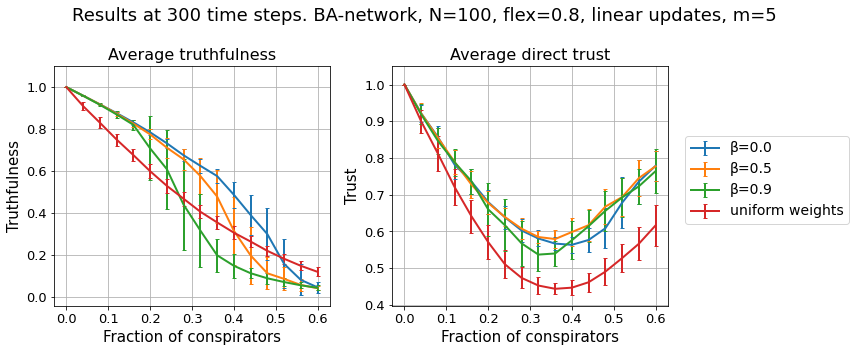

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\BA_100_linear\Results_at_300_time_steps._BA-network_N=100_flex=0.8_linear_updates_m=5.png


In [18]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\BA_100_linear"
plot_truthfulness_results(folder, 100, "BA", "linear", 0.8,  5)

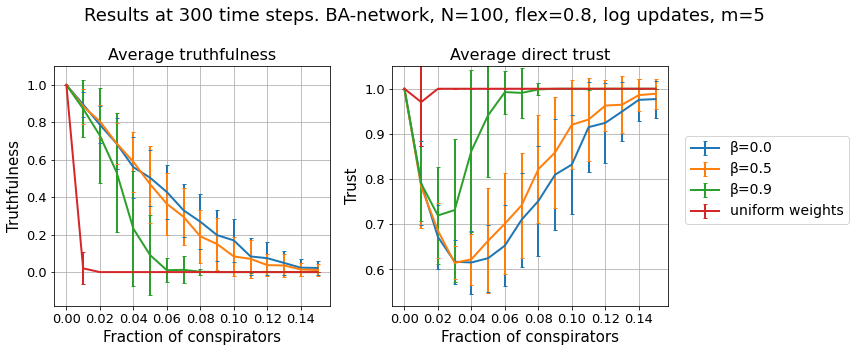

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\BA_100_log\Results_at_300_time_steps._BA-network_N=100_flex=0.8_log_updates_m=5.png


In [125]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\BA_100_log"
plot_truthfulness_results(folder, 100, "BA", "log", 0.8,  5, xticks=np.arange(0, 0.16, 0.02))

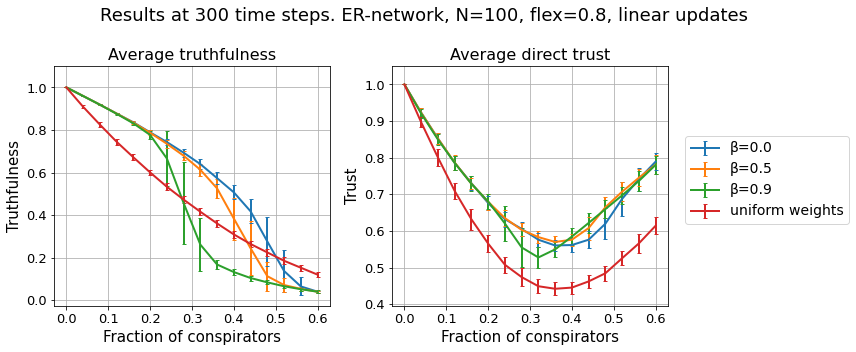

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\ER_100_linear\Results_at_300_time_steps._ER-network_N=100_flex=0.8_linear_updates.png


In [6]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\ER_100_linear"
plot_truthfulness_results(folder, 100, "ER", "linear", 0.8,  5)

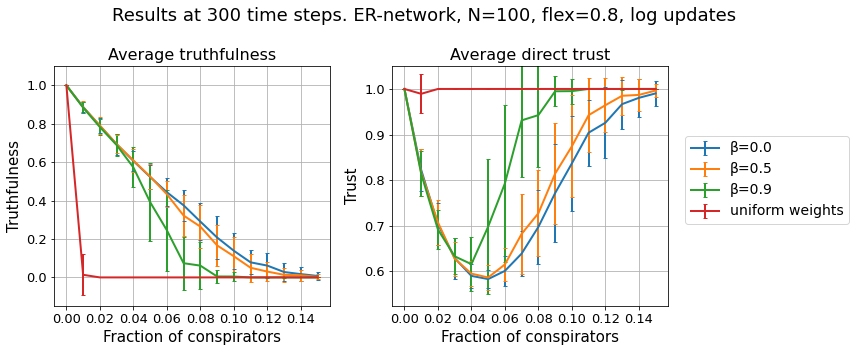

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\ER_100_log\Results_at_300_time_steps._ER-network_N=100_flex=0.8_log_updates.png


In [130]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Consp_truth\ER_100_log"
plot_truthfulness_results(folder, 100, "ER", "log", 0.8,  5, xticks=np.arange(0, 0.16, 0.02))

In [45]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_BA_linear_N100_250timesteps"
merge_simulation_files(folder)


Merging 2 files for group: N100_trust_a1.0_b0.0_thr1.0_numsim_iter250_flex0.8_BA_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b0.0_thr1.0_numsim80_iter250_flex0.8_BA_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_trust_a1.0_b1.0_thr1.0_numsim_iter250_flex0.8_BA_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b1.0_thr1.0_numsim80_iter250_flex0.8_BA_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_trust_a1.0_b1.5_thr1.0_numsim_iter250_flex0.8_BA_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b1.5_thr1.0_numsim80_iter250_flex0.8_BA_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_trust_a1.0_b2.0_thr1.0_numsim_iter250_flex0.8_BA_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b2.0_thr1.0_numsim80_iter250_flex0.8_BA_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_uniform_a1.0_b0.5_thr1.0_numsim_iter250_flex0.8_BA_clusters_linear.npz
Save

['C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_BA_linear_N100_250timesteps\\N100_trust_a1.0_b0.0_thr1.0_numsim80_iter250_flex0.8_BA_clusters_linear.npz',
 'C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_BA_linear_N100_250timesteps\\N100_trust_a1.0_b1.0_thr1.0_numsim80_iter250_flex0.8_BA_clusters_linear.npz',
 'C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_BA_linear_N100_250timesteps\\N100_trust_a1.0_b1.5_thr1.0_numsim80_iter250_flex0.8_BA_clusters_linear.npz',
 'C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_BA_linear_N100_250timesteps\\N100_trust_a1.0_b2.0_thr1.

In [55]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_ER_linear_N100_250timesteps"
merge_simulation_files(folder)


Merging 2 files for group: N100_trust_a1.0_b0.0_thr1.0_numsim_iter250_flex0.8_ER_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b0.0_thr1.0_numsim80_iter250_flex0.8_ER_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_trust_a1.0_b1.0_thr1.0_numsim_iter250_flex0.8_ER_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b1.0_thr1.0_numsim80_iter250_flex0.8_ER_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_trust_a1.0_b1.5_thr1.0_numsim_iter250_flex0.8_ER_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b1.5_thr1.0_numsim80_iter250_flex0.8_ER_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_trust_a1.0_b2.0_thr1.0_numsim_iter250_flex0.8_ER_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b2.0_thr1.0_numsim80_iter250_flex0.8_ER_clusters_linear.npz  (total simulations = 80)

Merging 2 files for group: N100_uniform_a1.0_b0.5_thr1.0_numsim_iter250_flex0.8_ER_clusters_linear.npz
Save

['C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_ER_linear_N100_250timesteps\\N100_trust_a1.0_b0.0_thr1.0_numsim80_iter250_flex0.8_ER_clusters_linear.npz',
 'C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_ER_linear_N100_250timesteps\\N100_trust_a1.0_b1.0_thr1.0_numsim80_iter250_flex0.8_ER_clusters_linear.npz',
 'C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_ER_linear_N100_250timesteps\\N100_trust_a1.0_b1.5_thr1.0_numsim80_iter250_flex0.8_ER_clusters_linear.npz',
 'C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_ER_linear_N100_250timesteps\\N100_trust_a1.0_b2.0_thr1.

In [8]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_BA_linear_N100_300timesteps_new"
merge_simulation_files(folder)

Skipping group (single file): N100_trust_a1.0_b0.0_thr1.0_numsim80_iter300_flex0.8_BA_clusters_linear.npz
Skipping group (single file): N100_trust_a1.0_b0.5_thr1.0_numsim80_iter300_flex0.8_BA_clusters_linear.npz

Merging 2 files for group: N100_trust_a1.0_b0.9_thr1.0_numsim_iter300_flex0.8_BA_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b0.9_thr1.0_numsim100_iter300_flex0.8_BA_clusters_linear.npz  (total simulations = 100)
Skipping group (single file): N100_uniform_a1.0_b0.5_thr1.0_numsim80_iter300_flex0.8_BA_clusters_linear.npz

Merging complete.


['C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_BA_linear_N100_300timesteps_new\\N100_trust_a1.0_b0.9_thr1.0_numsim100_iter300_flex0.8_BA_clusters_linear.npz']

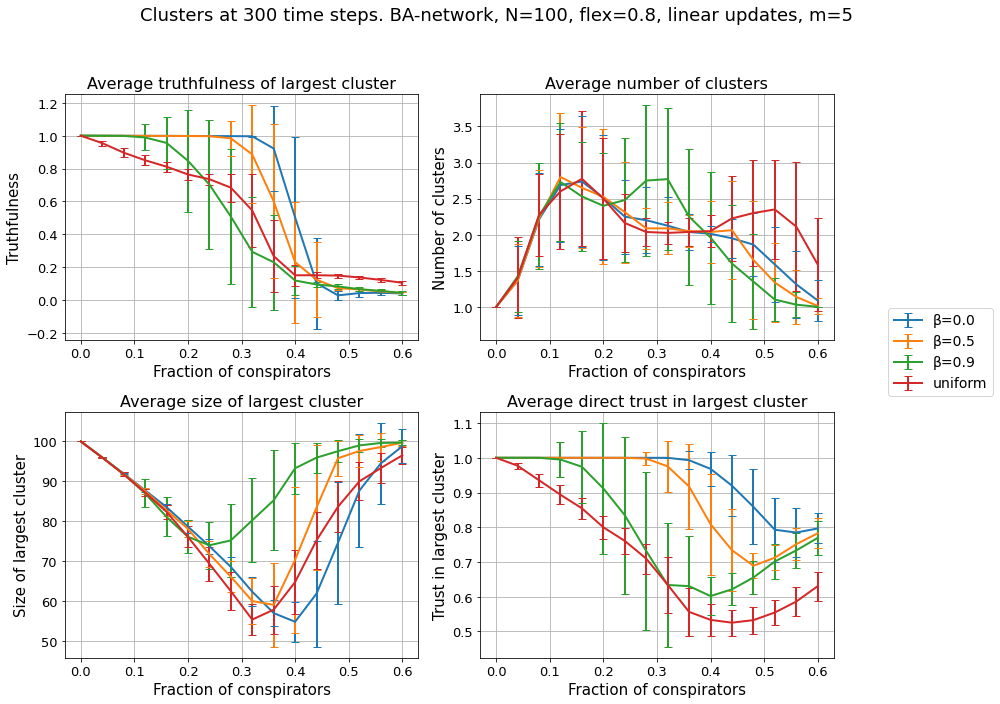

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_BA_linear_N100_300timesteps_new\Clusters_at_300_time_steps._BA-network_N=100_flex=0.8_linear_updates_m=5.png


In [118]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_BA_linear_N100_300timesteps_new"
plot_cluster_results(folder, 100, "BA", "linear", 0.8, m=5, time=300)

In [12]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_BA_log_N100_300timesteps_new"
merge_simulation_files(folder)


Merging 2 files for group: N100_trust_a1.0_b0.0_thr1.0_numsim_iter300_flex0.8_BA_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b0.0_thr1.0_numsim100_iter300_flex0.8_BA_clusters_linear.npz  (total simulations = 100)

Merging 2 files for group: N100_trust_a1.0_b0.5_thr1.0_numsim_iter300_flex0.8_BA_clusters_linear.npz
Saved merged file: N100_trust_a1.0_b0.5_thr1.0_numsim100_iter300_flex0.8_BA_clusters_linear.npz  (total simulations = 100)
Skipping group (single file): N100_trust_a1.0_b0.9_thr1.0_numsim80_iter300_flex0.8_BA_clusters_linear.npz
Skipping group (single file): N100_uniform_a1.0_b0.5_thr1.0_numsim80_iter300_flex0.8_BA_clusters_linear.npz

Merging complete.


['C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_BA_log_N100_300timesteps_new\\N100_trust_a1.0_b0.0_thr1.0_numsim100_iter300_flex0.8_BA_clusters_linear.npz',
 'C:\\Users\\bibia\\OneDrive\\OneDrive - NTNU\\5. klasse\\Prosjektoppgaven\\DHT-simulations-misinformation-propagation-main\\Data files\\Clusters\\Clusters_BA_log_N100_300timesteps_new\\N100_trust_a1.0_b0.5_thr1.0_numsim100_iter300_flex0.8_BA_clusters_linear.npz']

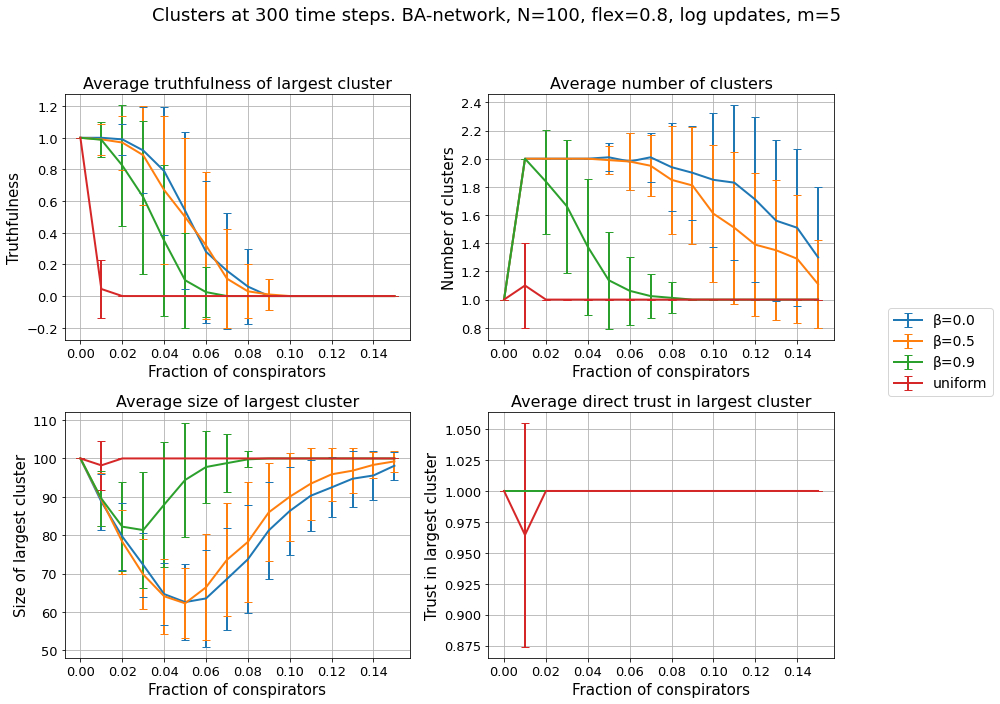

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_BA_log_N100_300timesteps_new\Clusters_at_300_time_steps._BA-network_N=100_flex=0.8_log_updates_m=5.png


In [101]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_BA_log_N100_300timesteps_new"
plot_cluster_results(folder, 100, "BA", "log", 0.8, m=5, time=300, xticks=np.arange(0, 0.15, 0.02))

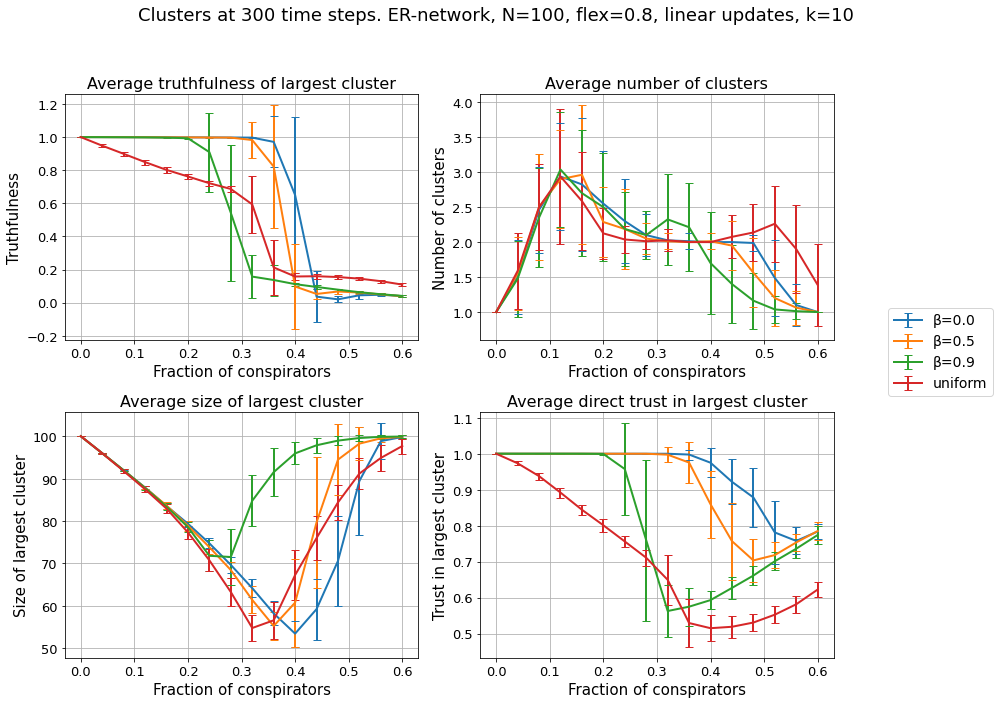

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_ER_linear_N100_300timesteps_new\Clusters_at_300_time_steps._ER-network_N=100_flex=0.8_linear_updates_k=10.png


In [102]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_ER_linear_N100_300timesteps_new"
plot_cluster_results(folder, 100, "ER", "linear", 0.8, k=10, time=300,)
#plot_cluster_variances(folder, 100, "ER", "linear", 0.8, m=5)

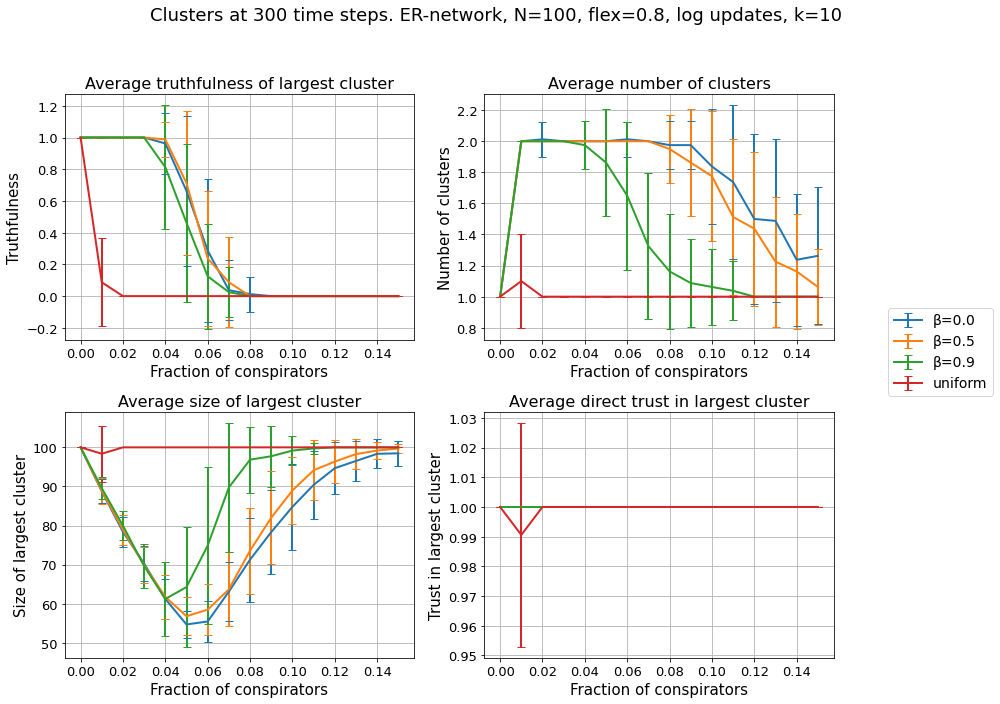

Saved to: C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_ER_log_N100_300timesteps_new\Clusters_at_300_time_steps._ER-network_N=100_flex=0.8_log_updates_k=10.png


In [103]:
folder = r"C:\Users\bibia\OneDrive\OneDrive - NTNU\5. klasse\Prosjektoppgaven\DHT-simulations-misinformation-propagation-main\Data files\Clusters\Clusters_ER_log_N100_300timesteps_new"
plot_cluster_results(folder, 100, "ER", "log", 0.8, k=10, time=300, xticks=np.arange(0, 0.15, 0.02))